In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import balanced_accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import ssefcca_functions as sfc

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from warnings import filterwarnings
filterwarnings('ignore', module='sklearn', category=UserWarning)

In [2]:
csv_folder = 'data/csv_files'
clf_folder = 'data/models'
ru_test_file = f'{csv_folder}/big_benchmark/ru_test.csv'

In [3]:
ru_test_df = pd.read_csv(ru_test_file)
print(ru_test_df['category'].value_counts())
print(f'Tot formulae: {ru_test_df['category'].value_counts().sum()}')
print(f'\nShannon diversity index: {sfc.Shannon_diversity_index(ru_test_df['category'])}')

category
peptide          1200
lipid             764
phytochemical     330
Name: count, dtype: int64
Tot formulae: 2294

Shannon diversity index: 0.9840598958468987


In [4]:
def get_formulae(df:pd.DataFrame) -> list[str]:
    '''
    Constructs a list of molecular formulae from the elemental composition columns in the dataframe.
    Parameters:

    df:
        A pandas DataFrame containing columns 'C', 'H', 'O', 'N', 'P', 'S' representing the counts of each element in the molecule.
    
    Returns:
        A list of strings, where each string is a molecular formula in the format 'C{c}H{h}O{o}N{n}P{p}S{s}'.
    '''
    return [f'C{c}H{h}O{o}N{n}P{p}S{s}' for c, h, o, n, p, s in df[['C', 'H', 'O', 'N', 'P', 'S']].astype(int).to_numpy()]

In [5]:
clf_training_df_path = f'{csv_folder}/new_vk_areas_df.csv'
clf_training_df = pd.read_csv(clf_training_df_path)

ru_test_formulae = get_formulae(ru_test_df)
clf_training_formulae = get_formulae(clf_training_df)

same_formulae_idx = [i for i, formula in enumerate(ru_test_formulae) if formula in clf_training_formulae]
print(f'Number of formulae matching between the datasets: {len(same_formulae_idx)}')

Number of formulae matching between the datasets: 760


In [6]:
ru_test_df_cropped = ru_test_df.drop(index=same_formulae_idx).reset_index(drop=True)
categories = np.unique(ru_test_df_cropped['category'])
class_weights_ru = compute_class_weight('balanced', classes=categories, y=ru_test_df_cropped['category'])
weights_dict_ru = {cls: weight for cls, weight in zip(categories, class_weights_ru)}
weights_ru = [weights_dict_ru[cat] for cat in ru_test_df_cropped['category']]

print(ru_test_df_cropped['category'].value_counts())
print(f'Tot formulae: {ru_test_df_cropped['category'].value_counts().sum()}')
print(f'\nShannon diversity index: {sfc.Shannon_diversity_index(ru_test_df_cropped['category'])}')

category
peptide          1197
phytochemical     257
lipid              80
Name: count, dtype: int64
Tot formulae: 1534

Shannon diversity index: 0.6469114199031625


In [7]:
# MSCC
y_pred_ru = sfc.molecclass(ru_test_df_cropped,sfc.rivasubach_areas,['O/C','H/C','N/C'])
# y_pred_ru_complete = sfc.molecclass(ru_test_df_cropped,sfc.rivasubach_areas_complete,['O/C','H/C','N/C','P/C','N/P'])

print(f'3D MSCC balanced accuracy: {balanced_accuracy_score(ru_test_df_cropped['category'],y_pred_ru,sample_weight=weights_ru)}')
print(f'Accuracy by class: {sfc.class_wise_accuracy(ru_test_df_cropped['category'], y_pred_ru)}\n')
# print(f'Complete MSCC balanced accuracy: {balanced_accuracy_score(ru_test_df_cropped['category'],y_pred_ru_complete,sample_weight=weights_ru)}')
# print(f'Accuracy by class: {sfc.class_wise_accuracy(ru_test_df_cropped['category'], y_pred_ru_complete)}')

3D MSCC balanced accuracy: 0.9682364417312196
Accuracy by class: {'lipid': 0.925, 'peptide': 0.9991645781119465, 'phytochemical': 0.980544747081712}



In [8]:
X_3d = clf_training_df[['O/C','H/C','N/C']].to_numpy()
y = clf_training_df['category'].to_numpy()
y[[x in ['pah','tannin','lignin'] for x in y]] = 'phytochemical'
class_weights_clf = compute_class_weight('balanced', classes=np.unique(y), y=y)
weights_dict_clf = {cls: weight for cls, weight in zip(np.unique(y), class_weights_clf)}
weights_clf = [weights_dict_clf[cat] for cat in y]

retrained_clf_dict = {
    'KNN': sfc.clf_pipeline(KNeighborsClassifier(**sfc.knn_param_3d)),
    'GNB': sfc.clf_pipeline(GaussianNB()),
    'Poly SVM': sfc.clf_pipeline(SVC(**sfc.svm_poly_param_3d,probability=True)),
    'RBF SVM': sfc.clf_pipeline(SVC(**sfc.svm_rbf_param_3d,probability=True))
}

for clf in retrained_clf_dict:
    
    weighted_kw = {'clf__sample_weight': weights_clf} if clf not in ['KNN'] else {}
    retrained_clf_dict[clf] = retrained_clf_dict[clf].fit(X_3d, y, **weighted_kw)
    y_pred = retrained_clf_dict[clf].predict(ru_test_df_cropped[['O/C','H/C','N/C']])
    print(f'{clf} balanced accuracy: {balanced_accuracy_score(ru_test_df_cropped['category'], y_pred, sample_weight=weights_ru)}')

    print(f'Accuracy by class for {clf}: {sfc.class_wise_accuracy(ru_test_df_cropped['category'], y_pred)}\n')

    class_indices = [i for i, class_ in enumerate(retrained_clf_dict[clf].classes_) if class_ in categories]
    y_pred_proba = retrained_clf_dict[clf].predict_proba(ru_test_df_cropped[['O/C','H/C','N/C']])[:, class_indices]

KNN balanced accuracy: 0.8263914352461352
Accuracy by class for KNN: {'lipid': 0.9625, 'peptide': 0.9991645781119465, 'phytochemical': 0.5175097276264592}

GNB balanced accuracy: 0.7731709163743772
Accuracy by class for GNB: {'lipid': 0.7375, 'peptide': 0.7259816207184628, 'phytochemical': 0.8560311284046692}



c:\Users\s2017658\.conda\envs\ssefcca\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\s2017658\.conda\envs\ssefcca\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\s2017658\.conda\envs\ssefcca\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\s2017658\.conda\envs\ssefcca\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was depreca

Poly SVM balanced accuracy: 0.920898238354208
Accuracy by class for Poly SVM: {'lipid': 0.8625, 'peptide': 0.985797827903091, 'phytochemical': 0.914396887159533}



c:\Users\s2017658\.conda\envs\ssefcca\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\s2017658\.conda\envs\ssefcca\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\s2017658\.conda\envs\ssefcca\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\s2017658\.conda\envs\ssefcca\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was depreca

RBF SVM balanced accuracy: 0.9187848160175623
Accuracy by class for RBF SVM: {'lipid': 0.8125, 'peptide': 0.9983291562238931, 'phytochemical': 0.9455252918287937}



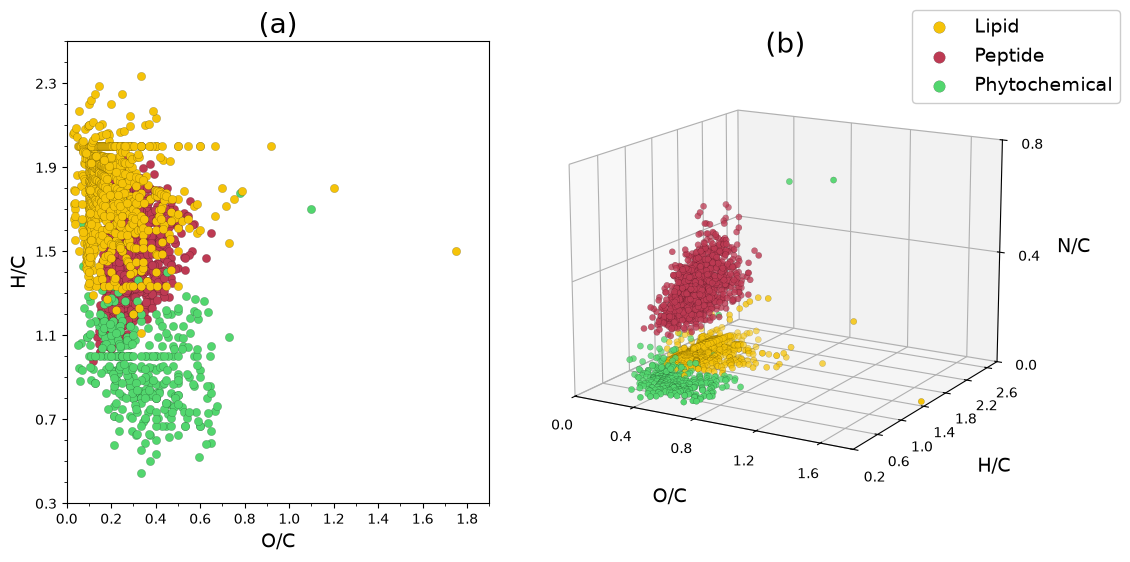

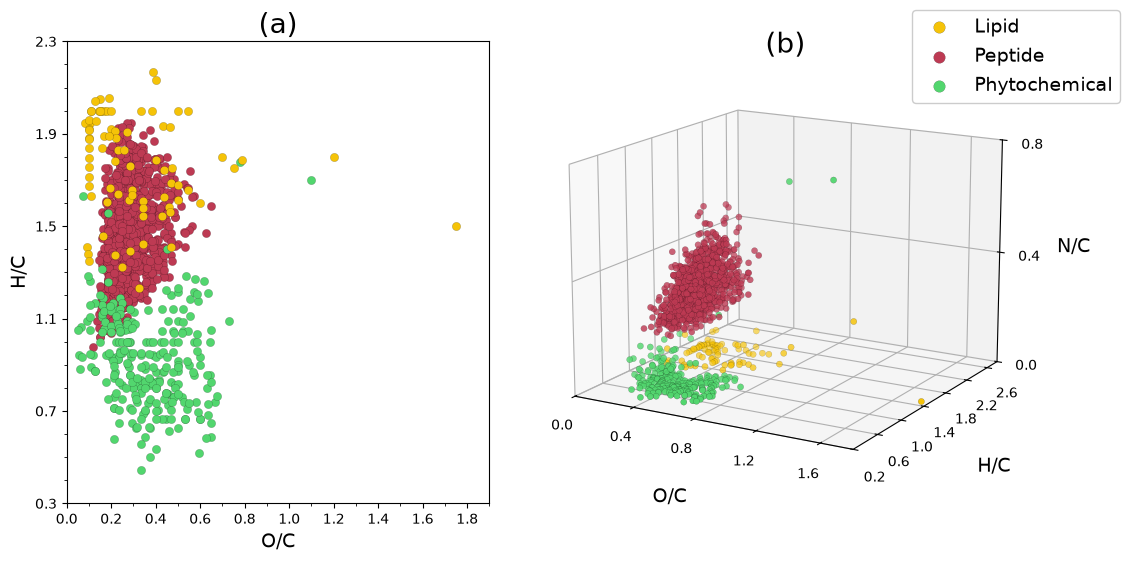

In [9]:
# Create Combined 2D and 3D Van Krevelen Diagram with PAHs
# Side-by-side comparison showing both perspectives

combos = [[ru_test_df,'before'],
          [ru_test_df_cropped,'after']]

for combo in combos:
    fig = plt.figure(figsize=(12, 6))

    # 2D Plot (subplot a)
    ax_2d = fig.add_subplot(121)

    for category in ['peptide','phytochemical','lipid',]:# 'peptide']:
        subset = combo[0][combo[0]['category'] == category]
        ax_2d.scatter(subset['O/C'], subset['H/C'],
                    c=sfc.vk_region_colours[category],
                    edgecolor='k', lw=.1)

    ax_2d.set_xlabel('O/C', fontsize=14)
    ax_2d.set_ylabel('H/C', fontsize=14)

    sfc.set_axis_ticks(combo[0]['O/C'].values, ax_2d, axis='x', major_ticks_interval=.2, minor_ticks_interval=.1, rounding=1, lower_lim=0)
    sfc.set_axis_ticks(combo[0]['H/C'].values, ax_2d, axis='y', major_ticks_interval=.4, minor_ticks_interval=.1, rounding=1)

    # 3D Plot (subplot b)
    ax_3d = fig.add_subplot(122, projection='3d')

    ax_3d.scatter(combo[0]['O/C'], combo[0]['H/C'], combo[0]['N/C'],
                c=[sfc.vk_region_colours[cat] for cat in combo[0]['category']],
                edgecolor='k', lw=.1)

    sfc.set_axis_ticks(combo[0]['O/C'], ax_3d, axis='x', major_ticks_interval=.4, minor_ticks_interval=None, rounding=1, lower_lim=min(0, 1.8), upper_lim=max(0, 1.8))
    sfc.set_axis_ticks(combo[0]['H/C'], ax_3d, axis='y', major_ticks_interval=.4, minor_ticks_interval=None, rounding=1, lower_lim=min(.2, 2.8), upper_lim=max(.2, 2.8))
    sfc.set_axis_ticks(combo[0]['N/C'], ax_3d, axis='z', major_ticks_interval=.4, minor_ticks_interval=None, rounding=1, lower_lim=min(0, .8), upper_lim=max(0, .8))

    # Create legend (shared between both plots)
    for cat in combo[0]['category'].unique():
        ax_3d.scatter(10, 10, 10, c=sfc.vk_region_colours[cat], alpha=1, edgecolor='k', lw=.1,
                    label=cat.replace('_', ' ').capitalize() if cat != 'pah' else 'PAH',
                    s=70)
        
    ax_3d.legend(framealpha=1, bbox_to_anchor=(.8, .9), loc='lower left', borderaxespad=0, fontsize=14)
    ax_3d.view_init(elev=15, azim=-60)

    ax_3d.set_xlabel('O/C', fontsize=14, labelpad=15)
    ax_3d.set_ylabel('H/C', fontsize=14, labelpad=15)
    ax_3d.set_zlabel('N/C', fontsize=14, labelpad=8)

    ax_3d.set_box_aspect(None, zoom=1.15)

    # Add subplot labels
    ax_2d.set_title('(a)', fontsize=20)
    ax_3d.set_title('(b)', fontsize=20)

    fig.savefig(f'data/plots/van_krevelens/vk_diagram_ru_validation_set_{combo[1]}.svg', dpi=600, facecolor='#fff', bbox_inches='tight')